In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install kaggle

In [5]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_3001ec4bebfdb7ea4b2d842ddb5107fe'

In [6]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.20
    Uninstalling kagglesdk-0.1.20:
      Successfully uninstalled kagglesdk-0.1.20
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [7]:
!mkdir -p ~/.kaggle

!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token

!chmod 600 ~/.kaggle/access_token

In [8]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          22975        487                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           2624         61                1  
nalisha/gaming-vs-academic-performance                              Gaming vs Academic Performance                          228280  2026-04-27 16:10:09.720000            595         23

In [10]:
!kaggle datasets list -s "covid ct scan"

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
andrewmvd/covid19-ct-scans                                      COVID-19 CT scans                                  1110427243  2020-04-23 12:29:33.323000          28634        592                1  
luisblanche/covidct                                             COVID-19 Lung CT Scans                               89959803  2020-04-09 12:08:48.423000           8299        114       0.88235295  
maedemaftouni/large-covid19-ct-slice-dataset                    Large COVID-19 CT scan slice dataset               2213688906  2021-06-10 18:13:10.747000           7718         88        0.8235294  
azaem

In [11]:
!kaggle datasets download -d plameneduardo/a-covid-multiclass-dataset-of-ct-scans

Dataset URL: https://www.kaggle.com/datasets/plameneduardo/a-covid-multiclass-dataset-of-ct-scans
License(s): Attribution 4.0 International (CC BY 4.0)
100% 405M/405M [00:08<00:00, 50.4MB/s]



In [12]:
!unzip a-covid-multiclass-dataset-of-ct-scans.zip

Archive:  a-covid-multiclass-dataset-of-ct-scans.zip
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132320.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132449.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132516.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132540.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132608.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132636.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132704.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132740.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132814.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132844.png  
  inflating: New_Data_CoV2/Covid/Patient (10)/AnotaтАб╓╢o 2020-04-28 132926.png  
  inflating: New_Data_CoV2/Covid/Patient (10)

In [13]:
import os

os.listdir('/content')

['.config',
 'a-covid-multiclass-dataset-of-ct-scans.zip',
 'New_Data_CoV2',
 'sample_data']

In [14]:
import os

os.listdir('/content/New_Data_CoV2')

['Healthy', 'Others', 'Covid']

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import numpy as np

In [16]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
dataset = datasets.ImageFolder(
    root='/content/New_Data_CoV2',
    transform=transform
)

print(dataset.classes)

['Covid', 'Healthy', 'Others']


In [18]:
targets = dataset.targets

train_idx, temp_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.30,
    stratify=targets,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=np.array(targets)[temp_idx],
    random_state=42
)

In [19]:
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [20]:
model = models.shufflenet_v2_x1_0(pretrained=True)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1`. You can also use `weights=ShuffleNet_V2_X1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 80.6MB/s]


In [21]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print(device)

cuda


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [23]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_acc = correct / total

    train_losses.append(running_loss)
    train_accuracies.append(epoch_acc)

    print(
        f'Epoch [{epoch+1}/{num_epochs}] '
        f'Accuracy: {epoch_acc:.4f}'
    )

Epoch [1/10] Accuracy: 0.7050
Epoch [2/10] Accuracy: 0.8304
Epoch [3/10] Accuracy: 0.8678
Epoch [4/10] Accuracy: 0.8839
Epoch [5/10] Accuracy: 0.9003
Epoch [6/10] Accuracy: 0.9102
Epoch [7/10] Accuracy: 0.9161
Epoch [8/10] Accuracy: 0.9318
Epoch [9/10] Accuracy: 0.9308
Epoch [10/10] Accuracy: 0.9527


In [24]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [25]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9073482428115016
Precision: 0.9086724768709914
Recall   : 0.9073482428115016
F1 Score : 0.9054502896401581


In [26]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[318   0   8]
 [  6 103   4]
 [ 31   9 147]]


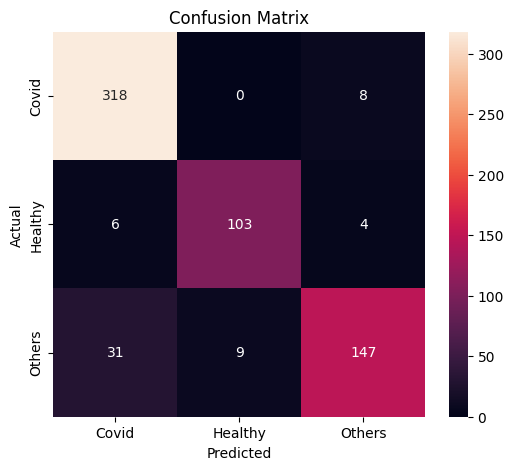

In [27]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

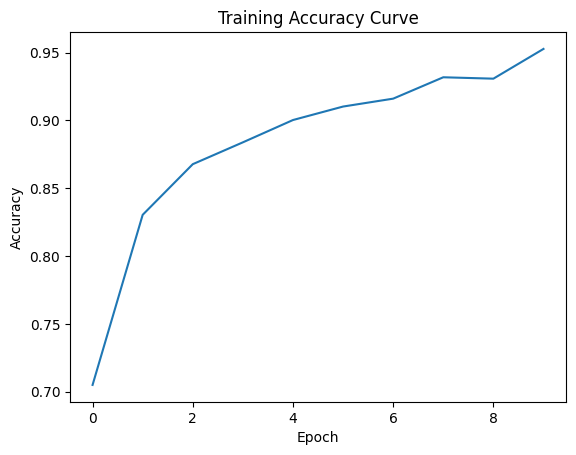

In [28]:
plt.plot(train_accuracies)

plt.title("Training Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

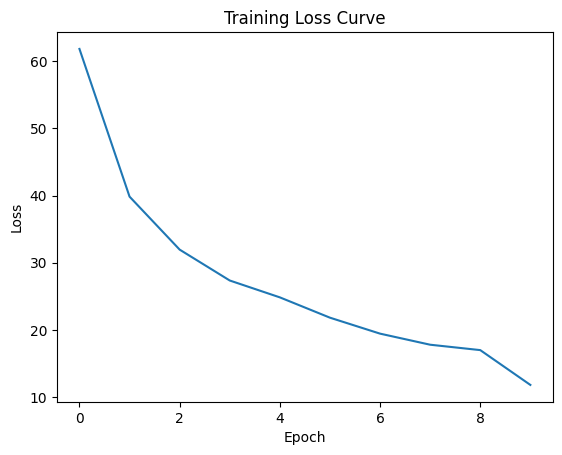

In [29]:
plt.plot(train_losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [30]:
torch.save(
    model.state_dict(),
    "shufflenetv2_covid19.pth"
)

In [31]:
from google.colab import files

files.download("shufflenetv2_covid19.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_bin = label_binarize(y_true, classes=[0,1,2])

model.eval()

y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        y_prob.extend(probs.cpu().numpy())

auc = roc_auc_score(
    y_true_bin,
    y_prob,
    multi_class='ovr'
)

print("AUC-ROC:", auc)

AUC-ROC: 0.9876476066800789
